This notebook not mine, use it for comparison

https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data

# Introduction

**Project Goal**

The goal of this machine learning project is to build a model that accurately predicts the selling price of a vehicle based on a set of influencing characteristics.  

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

import statsmodels.api as sm
from scipy.stats import gaussian_kde
from statsmodels.stats import diagnostic


from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction import FeatureHasher
from sklearn.experimental import enable_iterative_imputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


plt.style.use('ggplot')

ModuleNotFoundError: No module named 'missingno'

In [2]:
data = pd.read_csv('/kaggle/input/vehicle-sales-data/car_prices.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


## Project Overview

**Dataset Description**

* **Size:** We have 558,837 observations (data points). 
* **Features (16 total):**
    * **Quantitative Features (Features with numerical values)**
        * **year** (int64): The vehicle's manufacturing year.
        * **condition** (float64):  The condition of the vehicle (likely on a numerical scale).
        * **odometer** (float64): The vehicle's mileage.
        * **mmr** (float64):  The Manheim Market Report value (estimated market value).
        * **sellingprice** (float64): The final price at which the vehicle was sold.

    * **Qualitative Features (Features with categorical values)**
        * **make** (object): The vehicle's brand/manufacturer.
        * **model** (object):  The vehicle's specific model.
        * **trim** (object): Additional specification within the model.
        * **body** (object):  The vehicle's body type (e.g., Sedan, SUV, etc.).
        * **transmission** (object): The type of transmission (e.g., automatic, manual).
        * **vin** (object): The vehicle's unique Vehicle Identification Number.
        * **state** (object): The state where the vehicle is registered.
        * **color** (object): The vehicle's exterior color. 
        * **interior** (object): The vehicle's interior color.
        * **seller** (object): The entity that sold the vehicle.
        * **saledate** (object): The date and time of the sale.

**Notes**

* year and saledate should be converted to datetime format for easier analysis

In [3]:
data.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


## Missing Values and baseline

In [4]:
print(data.isnull().sum())

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64


**The dataset contains missing values, with varying frequencies across features. Here's a breakdown of missing counts per feature:**

* **year:** 0
* **make:** 10301
* **model:** 10399
* **trim:** 10651
* **body:** 13195
* **transmission:** 65352 
* **vin:** 4
* **state:** 0
* **condition:** 11820
* **odometer:** 94
* **color:** 749
* **interior:** 749
* **seller:** 0
* **mmr:** 38
* **sellingprice** 12
* **saledate** 12

**Observations:**

* The 'transmission' feature has the highest number of missing values (65,352).
* Features like 'year', 'state', and 'seller' have no missing data.
* Other features have relatively small amounts of missing values.


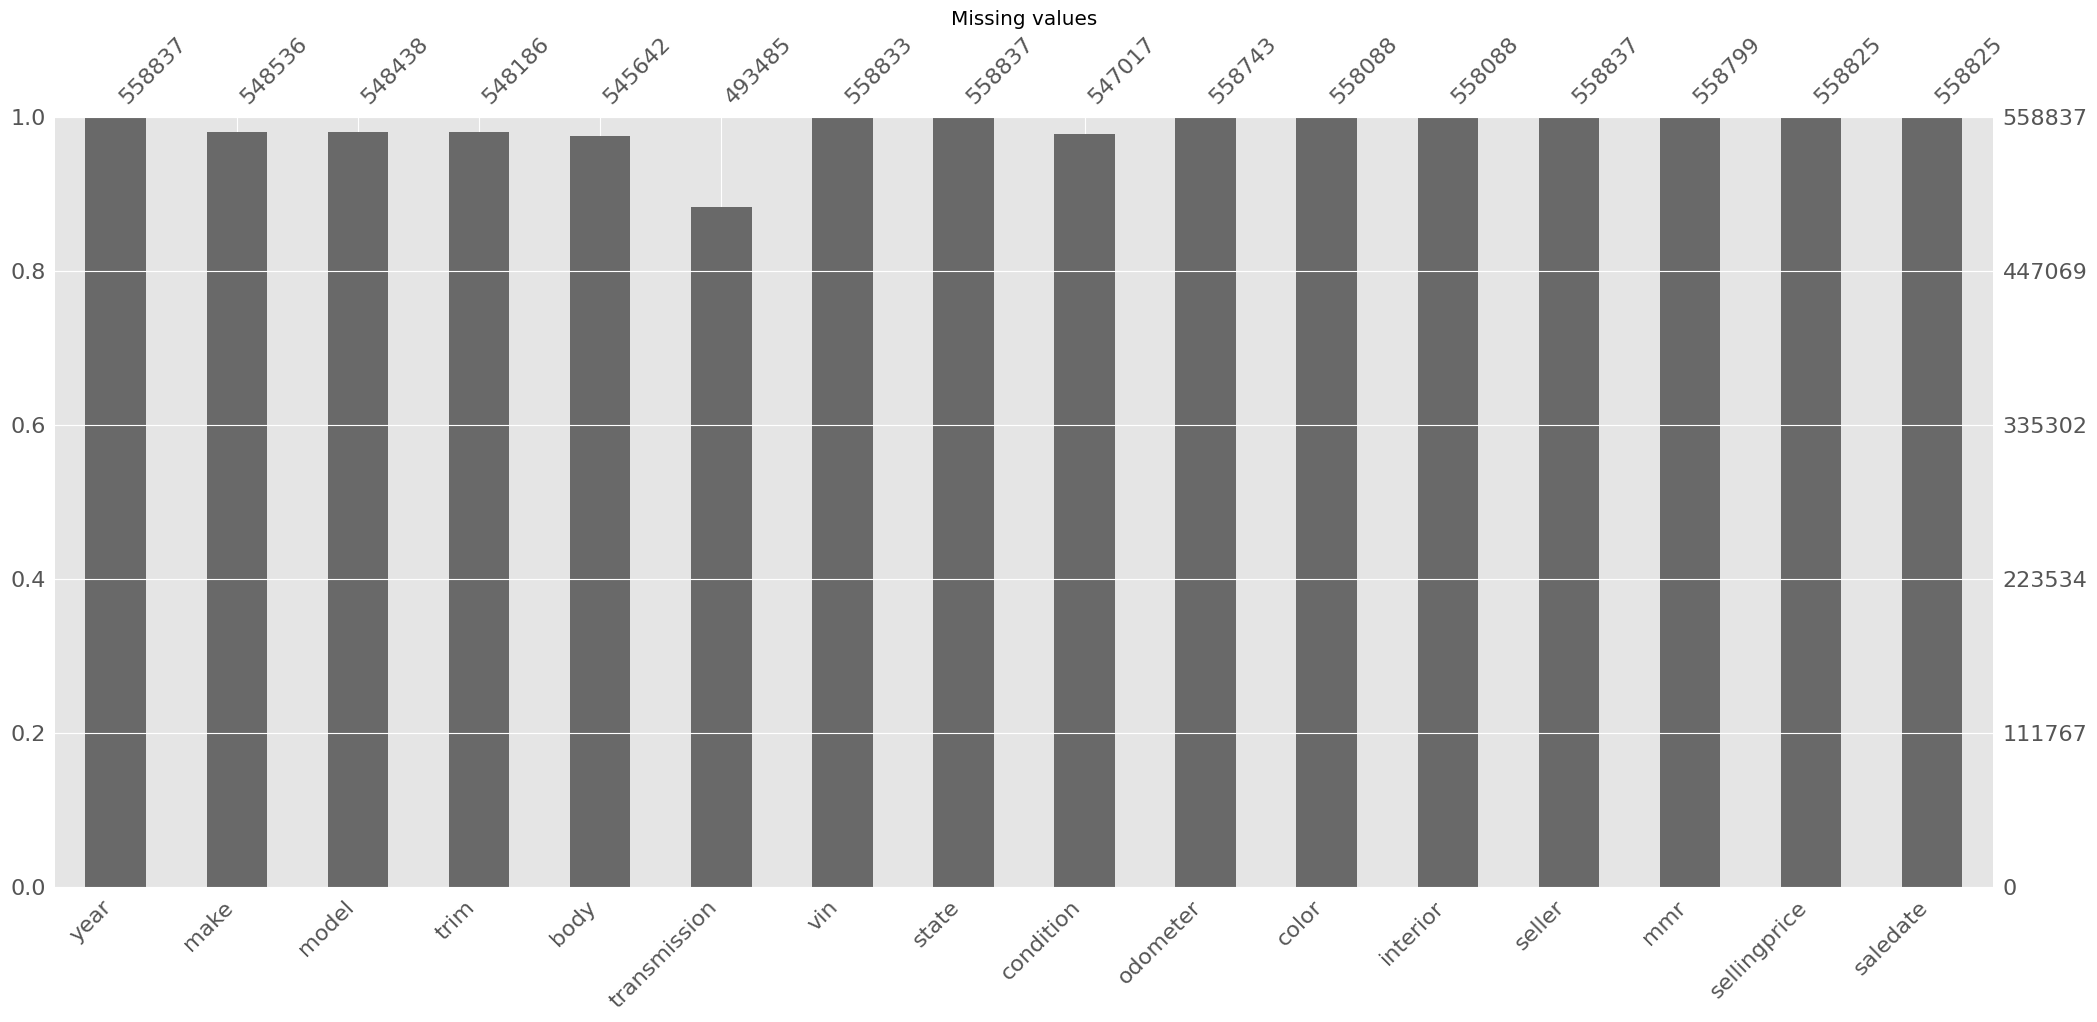

In [5]:
msno.bar(data)
plt.title('Missing values')
plt.show()

Prior to addressing missing data, I would like to establish a baseline using Simple Linear Regression. We have a feature called 'mmr' which indicates the estimated car's price. I assume that this feature will have a linear relationship with the target (which I will verify). I will fit a Simple Linear Regression model using this feature as the independent variable and the 'sellingprice' as the target variable.

### Handling Missing values

In [6]:
data.loc[:,'make'] = data.loc[:,['make']].fillna(data['make'].mode()[0])
data.loc[:,'model'] = data.loc[:,['model']].fillna(data['model'].mode()[0])
data.loc[:,'body'] = data.loc[:,['body']].fillna(data['body'].mode()[0])
data.loc[:,'trim'] = data.loc[:,['trim']].fillna(data['trim'].mode()[0])
data.loc[:,'color'] = data.loc[:,['color']].fillna(data['color'].mode()[0])
data.loc[:,'interior'] = data.loc[:,['interior']].fillna(data['interior'].mode()[0])
data.loc[:,'transmission'] = data.loc[:,['transmission']].fillna(data['transmission'].mode()[0])

data.loc[:,'condition'] = data.loc[:,['condition']].fillna(data['condition'].mean())
data.loc[:,'odometer'] = data.loc[:,['odometer']].fillna(data['odometer'].mean())
data.loc[:,'mmr'] = data.loc[:,['mmr']].fillna(data['mmr'].mean())

data.dropna(subset=['sellingprice'],axis='rows',inplace=True)

I filled in most missing values using the mode and median, tailoring my approach to the data distribution.  The 'transmission' column was trickier due to the high number of missing values. While predictive imputation seemed logical, the significant imbalance suggested the gains wouldn't justify the computational cost. So, I opted for mode imputation as a more efficient solution.

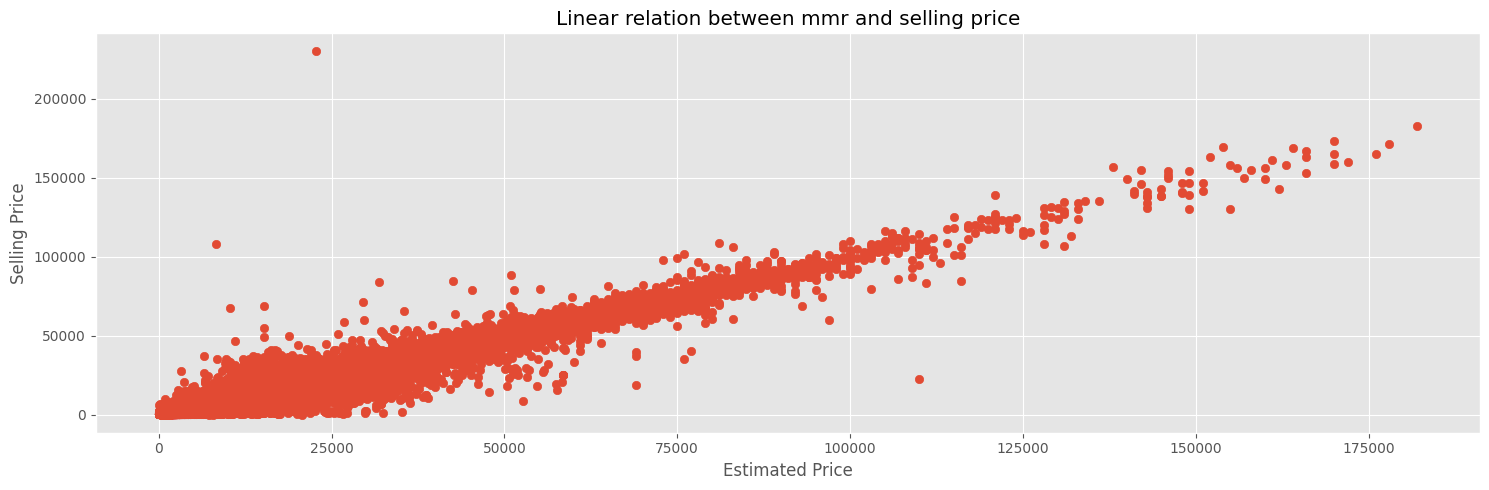

In [7]:
plt.figure(figsize=(15,5))
plt.scatter(data['mmr'],data['sellingprice'])
plt.xlabel("Estimated Price")
plt.ylabel('Selling Price')
plt.title("Linear relation between mmr and selling price")
plt.tight_layout()
plt.show()

**As expected, there is a linear relationship between mmr and sellingprice**

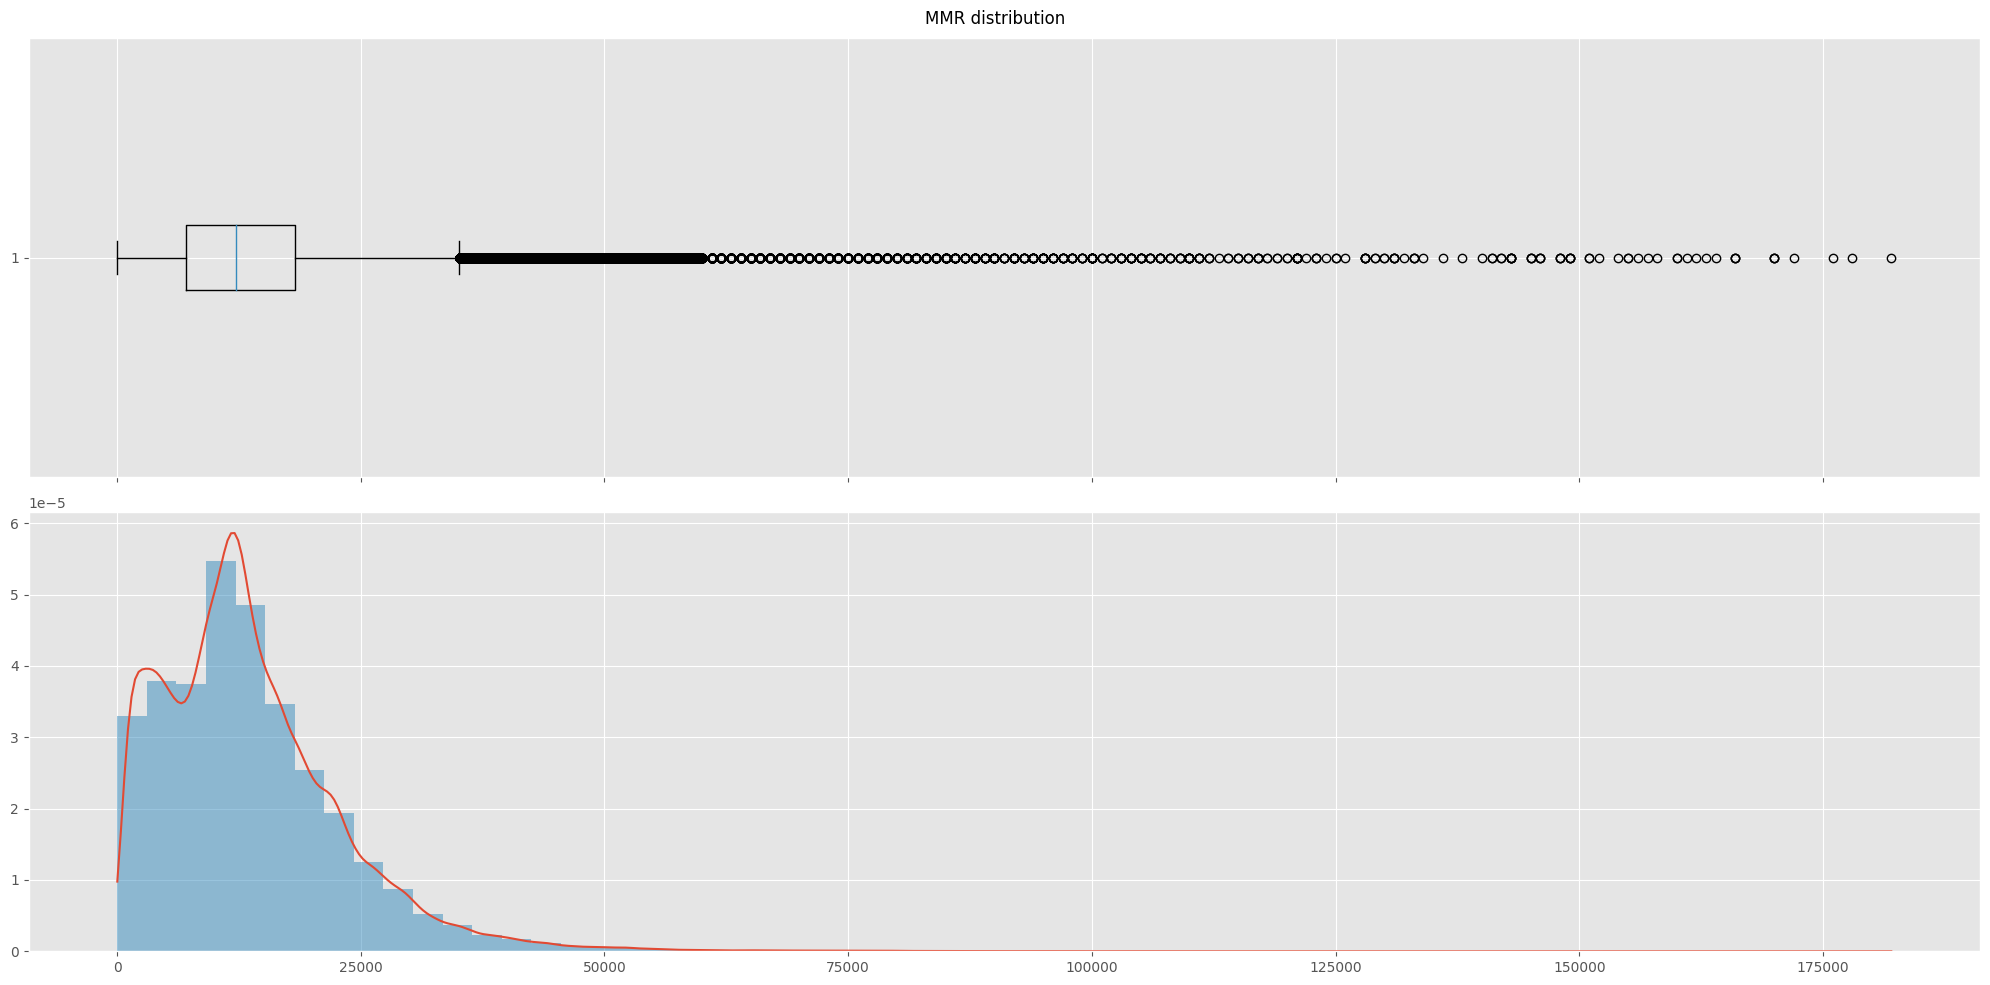

In [8]:
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(20,10),sharex=True)

kde = gaussian_kde(data['mmr'])
kde_x = np.linspace(data['mmr'].min(), data['mmr'].max(), 500)

ax[0].boxplot(data['mmr'],vert=False)

kde_y = kde(kde_x)

ax[1].plot(kde_x, kde_y, label='KDE')
ax[1].hist(data['mmr'],bins=60,alpha=0.5,density=True)

plt.suptitle('MMR distribution')
plt.tight_layout()
plt.show()

The distribution demonstrates a strong positive skew with a significant number of outliers.

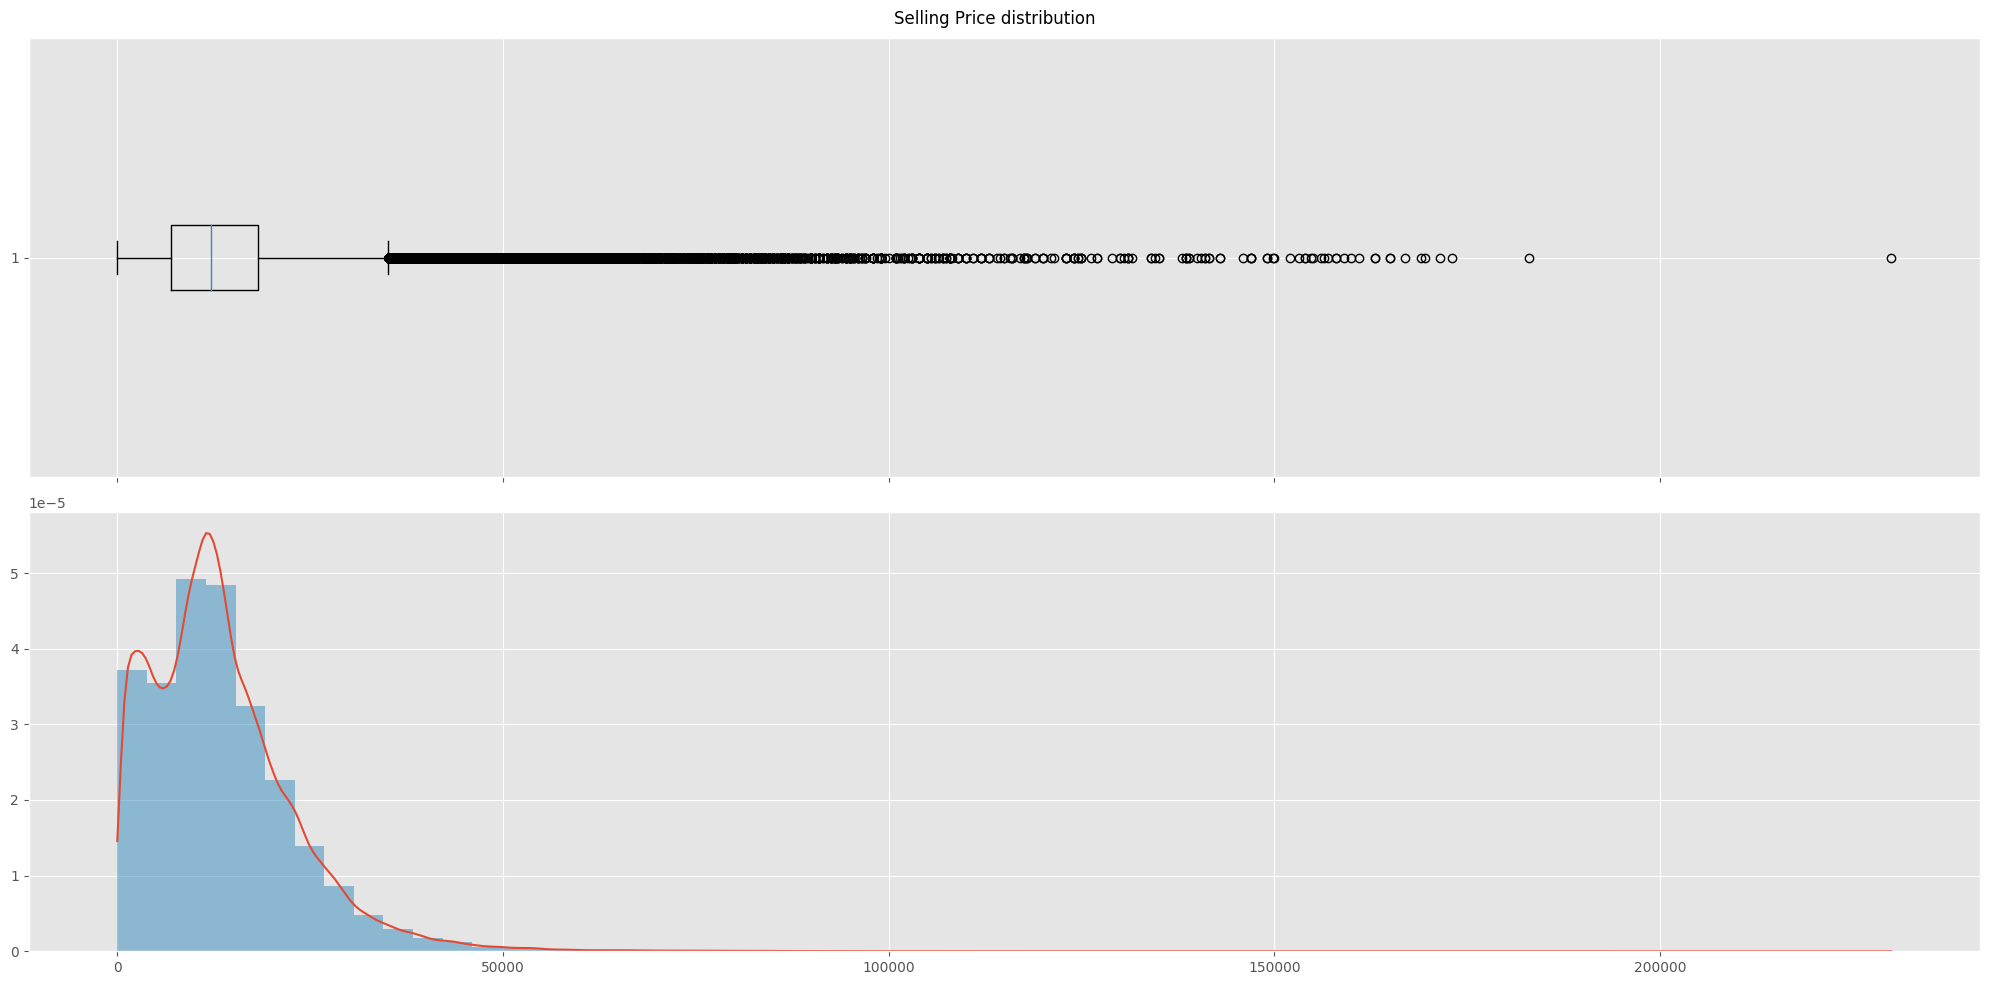

In [9]:
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(20,10),sharex=True)

kde = gaussian_kde(data['sellingprice'])
kde_x = np.linspace(data['sellingprice'].min(), data['sellingprice'].max(), 500)

ax[0].boxplot(data['sellingprice'],vert=False)

kde_y = kde(kde_x)

ax[1].plot(kde_x, kde_y, label='KDE')
ax[1].hist(data['sellingprice'],bins=60,alpha=0.5,density=True)

plt.suptitle('Selling Price distribution')
plt.tight_layout()
plt.show()

same as above,The distribution demonstrates a strong positive skew with a significant number of outliers.

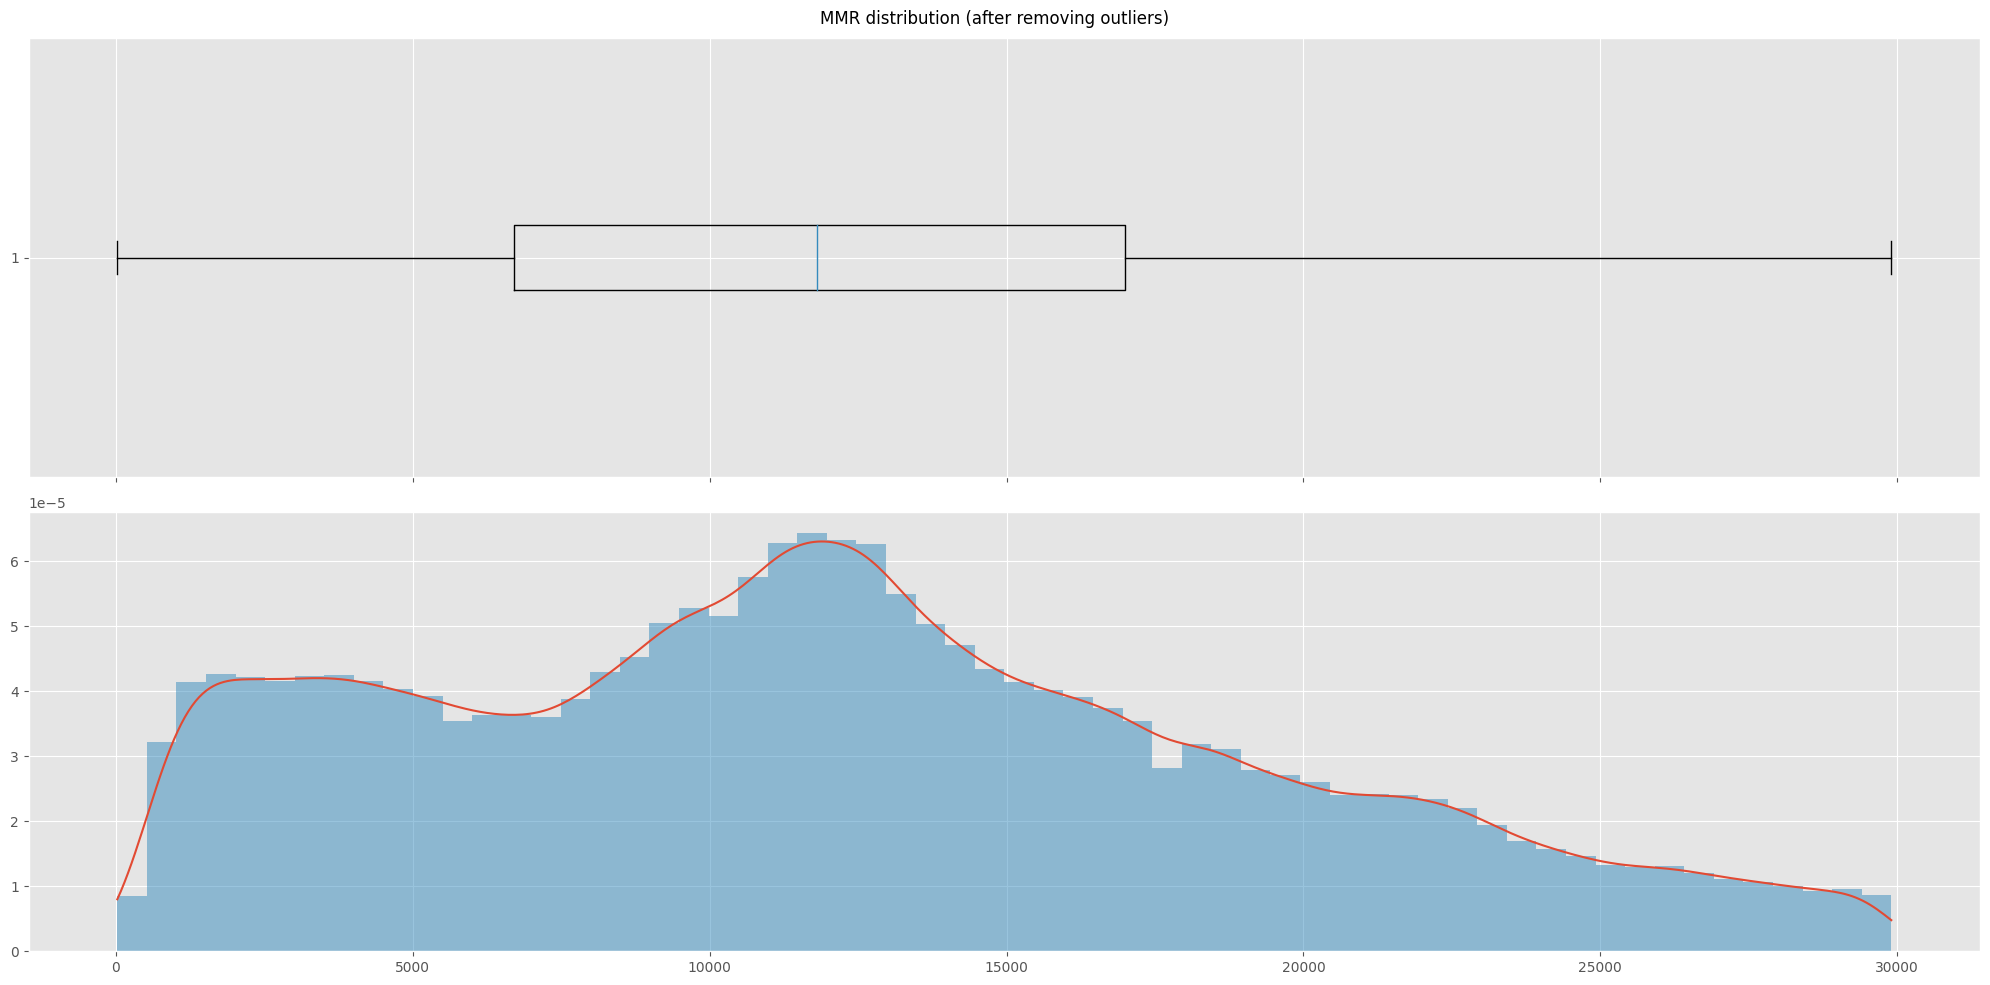

In [10]:
data1 = data.loc[data['mmr'] < 30000,:]

fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(20,10),sharex=True)

kde = gaussian_kde(data1['mmr'])
kde_x = np.linspace(data1['mmr'].min(), data1['mmr'].max(), 500)

ax[0].boxplot(data1['mmr'],vert=False)

kde_y = kde(kde_x)

ax[1].plot(kde_x, kde_y, label='KDE')
ax[1].hist(data1['mmr'],bins=60,alpha=0.5,density=True)

plt.suptitle('MMR distribution (after removing outliers)')
plt.tight_layout()
plt.show()

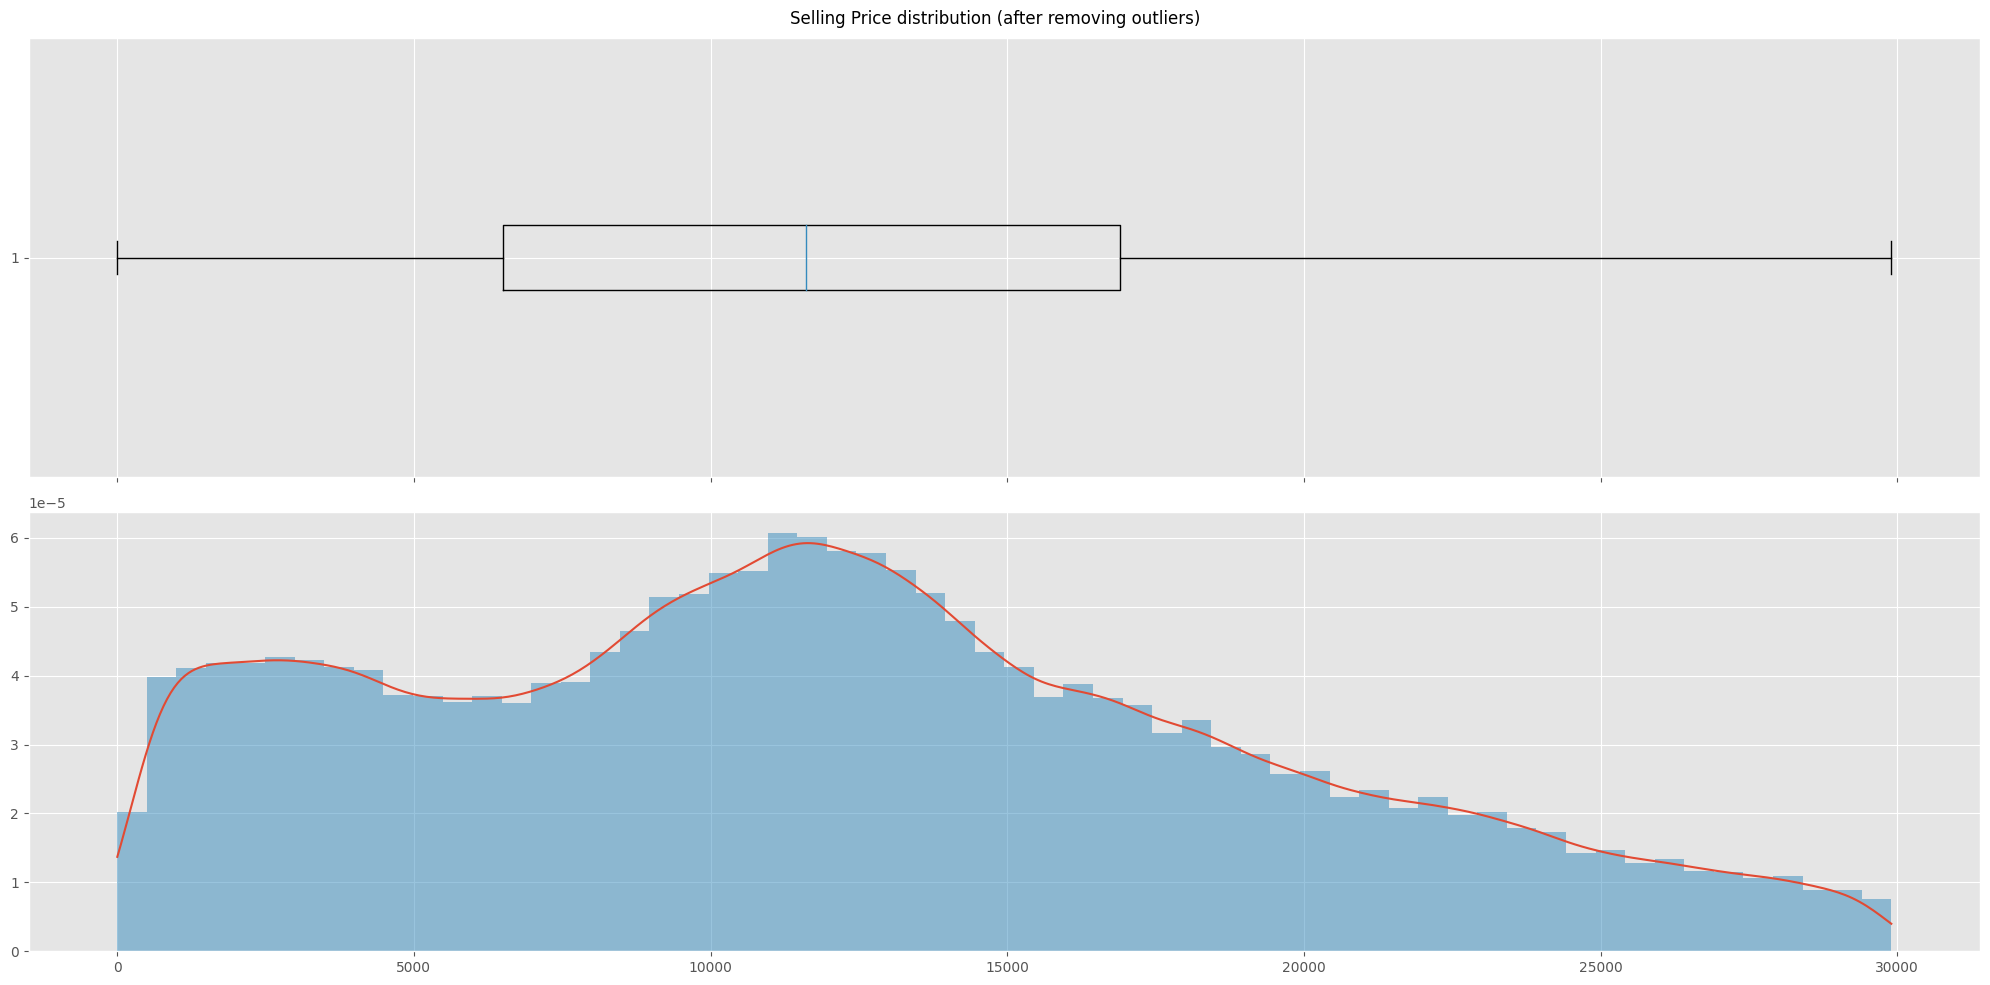

In [11]:
data1 = data.loc[data['sellingprice'] < 30000,:]

fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(20,10),sharex=True)

kde = gaussian_kde(data1['sellingprice'])
kde_x = np.linspace(data1['sellingprice'].min(), data1['sellingprice'].max(), 500)

ax[0].boxplot(data1['sellingprice'],vert=False)

kde_y = kde(kde_x)

ax[1].plot(kde_x, kde_y, label='KDE')
ax[1].hist(data1['sellingprice'],bins=60,alpha=0.5,density=True)

plt.suptitle('Selling Price distribution (after removing outliers)')
plt.tight_layout()
plt.show()

In [1]:
def print_metrics(model,X_train,X_test,y_train,y_test):
    predictions_train = model.predict(X_train) 
    predictions_test = model.predict(X_test)

    final_mse_train = mean_squared_error(y_train, predictions_train)
    final_mse_test = mean_squared_error(y_test, predictions_test)

    print(f'Final RMSE on the train set: {np.sqrt(final_mse_train)}')
    print(f'Final RMSE on the test set: {np.sqrt(final_mse_test)}')

In [13]:
X  = data1['mmr']
y = data1['sellingprice']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 1)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model = sm.OLS(y_train,X_train_const).fit()
print(model.summary())


print('=='*60)
predictions = model.predict(X_test_const)
print_metrics(model,X_train_const,X_test_const,y_train,y_test)

                            OLS Regression Results                            
Dep. Variable:           sellingprice   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                 7.812e+06
Date:                Thu, 14 Mar 2024   Prob (F-statistic):               0.00
Time:                        17:50:22   Log-Likelihood:            -3.7218e+06
No. Observations:              422463   AIC:                         7.444e+06
Df Residuals:                  422461   BIC:                         7.444e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         88.5361      4.973     17.805      0.0

The results of the OLS regression model suggest that the model is a good fit. The R-squared and adjusted R-squared values are both very high (0.949), which suggests that a very high proportion of the variation in selling price is explained by the independent variable(s) in the model. The F-statistic is also high and statistically significant, which suggests that the model as a whole is significant. The Durbin-Watson statistic is close to 2, which suggests that there is no serial correlation in the errors of the model.

However, the diagnostic tests also suggest that there may be some problems with the model. The Omnibus test and the Jarque-Bera test are both statistically significant, which suggests that the normality assumption of OLS regression may be violated. The condition number is large, which suggests that there may be multicollinearity among the independent variables but since we have only single feature we can safely ignore it for now.

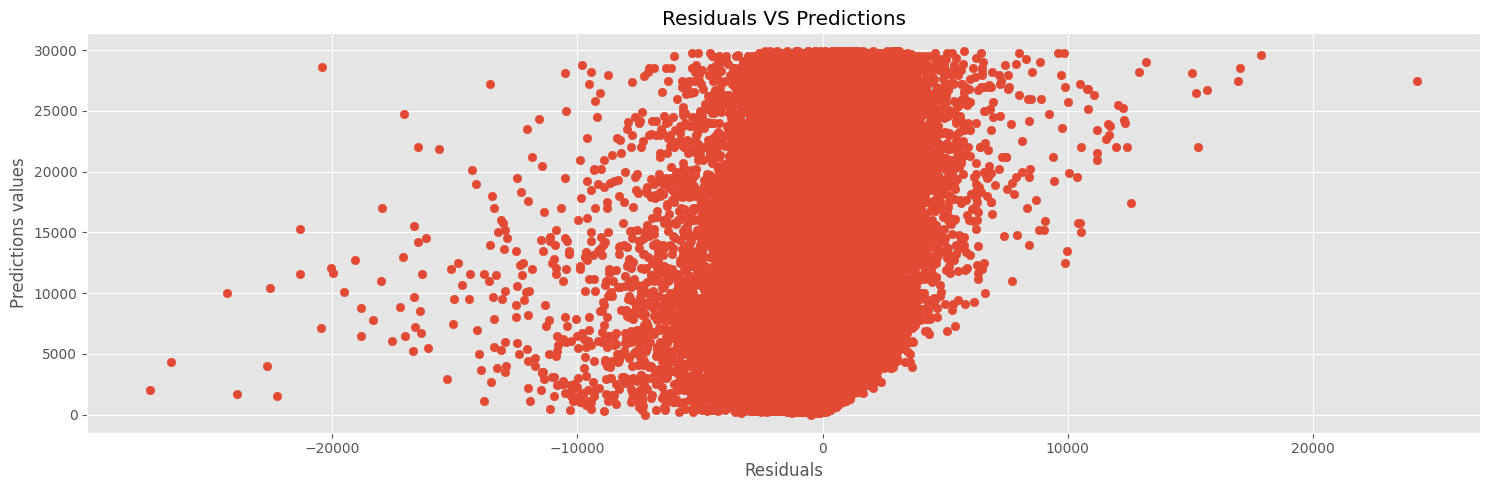

In [14]:
residuals = (y_test - predictions)
plt.figure(figsize=(15,5))
plt.scatter(residuals,y_test)
plt.xlabel('Residuals')
plt.ylabel('Predictions values')
plt.title('Residuals VS Predictions')
plt.tight_layout()
plt.show()

The spread of the data is uneven, forming a funnel shape. This strongly indicates heteroscedasticity rather than homoscedasticity.

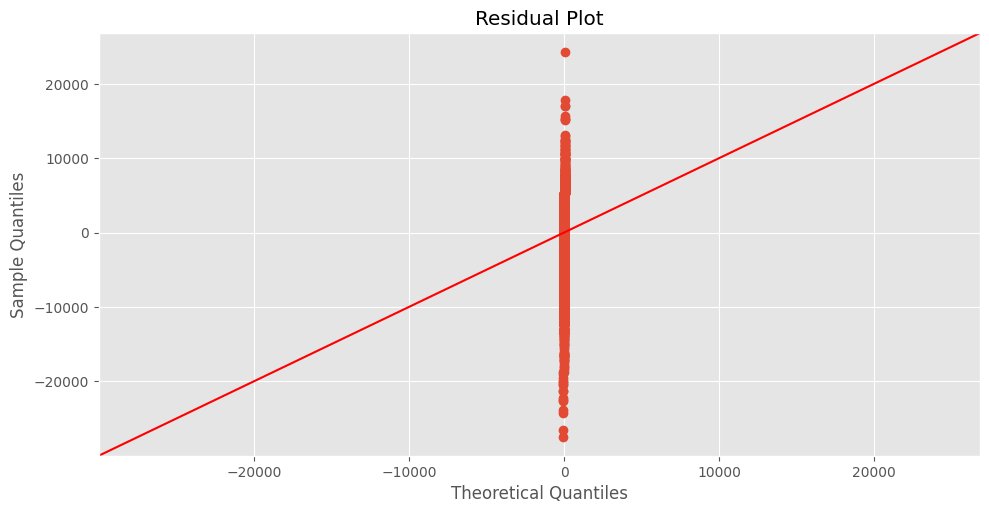

In [15]:
fig,ax = plt.subplots(figsize=(10,5))
fig = sm.qqplot(residuals,line='45',scale=10,ax=ax)
plt.tight_layout()
plt.title('Residual Plot')
plt.show()

QQ plots solidifies our findings from Omnibus test and the Jarque-Bera test

This Simple Linear regression model with **RMSE** of 1591 serves as baseline for the rest of the project

# Multilinear regression

With so many categorical variables, nonlinear models like decision trees or random forests are likely a good fit. Still, a linear regression could give us a useful comparison point.

Now before going ahead let's address missing values

In [16]:
data = data1.sample(frac=0.5,random_state=1,ignore_index=True)
data.drop(['seller','vin','saledate'],axis=1,inplace=True)
print(data.shape)
data.head()

(264040, 13)


,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,mmr,sellingprice
0,2000,Mercedes-Benz,S-Class,S430,Sedan,automatic,az,1.0,180536.0,black,black,1675.0,900.0
1,2012,Chrysler,200,Touring,Sedan,automatic,il,19.0,43541.0,blue,black,9475.0,8600.0
2,2009,Nissan,Versa,1.8 S,Hatchback,automatic,fl,3.0,85534.0,red,black,4450.0,4600.0
3,2013,Chevrolet,Impala,LT Fleet,Sedan,automatic,fl,38.0,52947.0,white,black,9300.0,9800.0
4,2014,Volkswagen,Tiguan,S,suv,automatic,fl,49.0,24415.0,blue,black,15300.0,15100.0


In [17]:
categorical_cols = ['make', 'model', 'trim', 'body', 'state', 'color', 'interior', 'transmission']
for col in categorical_cols:
    print(f"{col}: {data[col].nunique()}")

make: 84
model: 852
trim: 1637
body: 76
state: 49
color: 31
interior: 17
transmission: 4


In [18]:
for col in categorical_cols:
    counts = data[col].value_counts()
    other_categories = counts[counts <= 10].index.tolist()
    data[col] = data[col].apply(lambda x: 'Other' if x in other_categories else x)

In [19]:
categorical_cols = ['make', 'model', 'trim', 'body', 'state', 'color', 'interior', 'transmission']
for col in categorical_cols:
    print(f"{col}: {data[col].nunique()}")

make: 69
model: 585
trim: 750
body: 62
state: 38
color: 20
interior: 17
transmission: 3


In [20]:
data['cars_age'] = data['year'].apply(lambda x : 2015 - x)

data = pd.get_dummies(data=data,columns=['transmission'],drop_first=True,dtype=int)

encoder = ce.binary.BinaryEncoder(cols=['make','body','interior','color','state'],drop_invariant=True).fit(data)
data = encoder.transform(data)

hasher = FeatureHasher(n_features=40, input_type='string')
hashed_features = hasher.transform(data[['model','trim']].astype(str).to_numpy())
hashed_features_df = pd.DataFrame(hashed_features.toarray())
hashed_features_df.columns = ['hashed_feature_' + str(i) for i in range(hashed_features_df.shape[1])]

data.drop(['year','model', 'trim'],axis=1,inplace=True)
data = pd.concat([data,hashed_features_df],axis=1)

data.head()

,make_0,make_1,make_2,make_3,make_4,make_5,make_6,body_0,body_1,body_2,...,hashed_feature_30,hashed_feature_31,hashed_feature_32,hashed_feature_33,hashed_feature_34,hashed_feature_35,hashed_feature_36,hashed_feature_37,hashed_feature_38,hashed_feature_39
0,0,0,0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,0,0,0,1,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,0,0,0,0,0,...,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,1,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Our dataset contains numerous categorical variables, necessitating their encoding into numerical formats for compatibility with machine learning algorithms. Since these features are nominal, one-hot encoding would be a logical choice over label encoding. However, certain features, like 'model,' have an extensive number of unique categories (over 700). One-hot encoding would lead to excessive dimensionality, potentially hindering model performance. Therefore, I've opted for multiple techniques from grouping to binary encoding , one hotencoding , feature hashing depending on unique categories

from above plot we can see that MMR (Market-to-Market Rate) has a strong positive correlation with our target variable, Selling Price as expectedand Odometer and Cars Age have a negative correlation. That makes sense when you think about it - older cars with higher mileage tend to be less valuable. And finally, Condition shows a mild positive correlation. So, all things being equal, a car in good condition will fetch a slightly higher price."

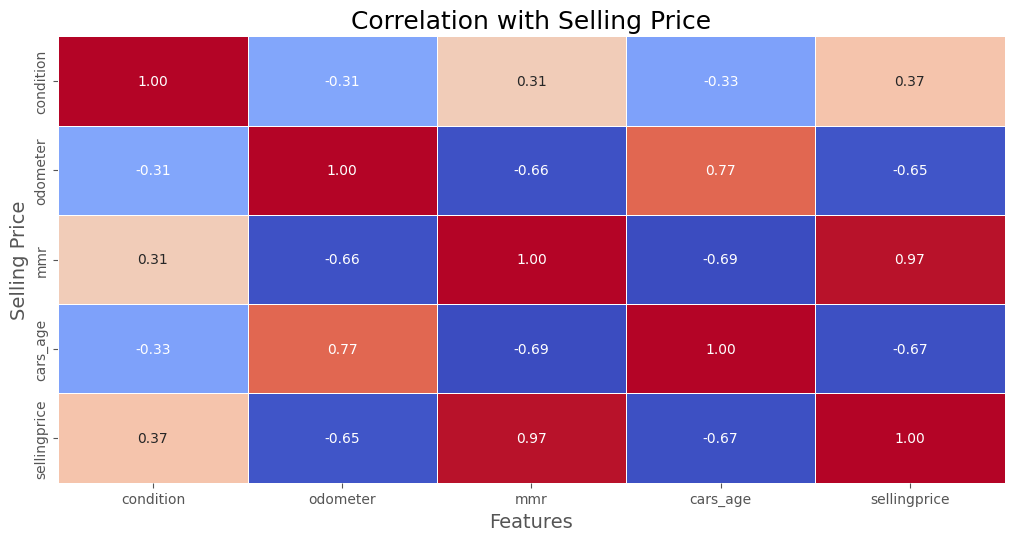

In [21]:
plt.figure(figsize=(10, 5))
numeric_cols = ['condition','odometer','mmr','cars_age','sellingprice']

sns.heatmap(data[numeric_cols].corr(),
            cmap='coolwarm',
            annot=True,
            fmt='.2f',               
            linewidths=0.5,          
            cbar = False,             
            )

plt.tight_layout()
plt.title('Correlation with Selling Price', fontsize=18)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Selling Price', fontsize=14)
plt.show()


In [22]:
X = data.drop(['sellingprice','transmission_automatic','mmr','cars_age','interior_4','condition'],axis=1)
y = data['sellingprice']
X_const = sm.add_constant(X)

In [23]:
# VIF = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns)

# print(VIF[VIF > 5])

removed 'transmission_automatic','mmr','cars_age''interior_4','condition' for high VIF scores

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X_const,y,test_size = 0.2,random_state = 1)

model = sm.OLS(y_train,X_train).fit()
print(model.summary())

predictions = model.predict(X_test)


print('=='*60)
print_metrics(model,X_train,X_test,y_train,y_test)

                            OLS Regression Results                            
Dep. Variable:           sellingprice   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     4114.
Date:                Thu, 14 Mar 2024   Prob (F-statistic):               0.00
Time:                        17:50:38   Log-Likelihood:            -2.0838e+06
No. Observations:              211232   AIC:                         4.168e+06
Df Residuals:                  211161   BIC:                         4.169e+06
Df Model:                          70                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.799e+04    

**After addressing multicollinearity by removing some features (measured by VIF), I used an OLS linear regression model.  Unfortunately, the performance dropped compared to the simple linear regression. The R-squared decreased from 0.949 to 0.577, and the RMSE worsened from 1591 to 4662. This confirms our suspicion that a linear model might not be the best fit.  Let's explore some non-linear modeling options next.**

# Decission Trees

In [25]:
X = data.drop(['sellingprice'],axis=1)
y = data['sellingprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# k = 5  
# alpha_range = np.linspace(1000, 2000, 3)  

# optimal_alpha = None
# min_error = float('inf')

# kf = KFold(n_splits=k, shuffle=True, random_state=42)

# for alpha in alpha_range:
#     print(alpha)
#     model = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42)

    
#     mse_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
#     mean_mse = -1 * np.mean(mse_scores) 

#     if mean_mse < min_error:
#         min_error = mean_mse
#         optimal_alpha = alpha


# print(f'Optimal alpha: {optimal_alpha}')


model = DecisionTreeRegressor(ccp_alpha=1000, random_state=42)
model.fit(X_train, y_train)

print_metrics(model,X_train,X_test,y_train,y_test)


Final RMSE on the train set: 1364.8474190475492
Final RMSE on the test set: 1386.1919595368242


# Random Forest

In [27]:
model = RandomForestRegressor(n_estimators=100, 
                                      random_state=42,
                                      max_depth = 16,
                                      max_features=0.3,
                                      bootstrap=True,
                                      max_samples=0.5,
                                      ccp_alpha = 1000,
                                      n_jobs=-1) 


model.fit(X_train, y_train)

print_metrics(model,X_train,X_test,y_train,y_test)

Final RMSE on the train set: 1325.0964043115123
Final RMSE on the test set: 1354.055299290067


# Gradient Boosting

In [28]:
model = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)

model.fit(X_train, y_train)

print_metrics(model,X_train,X_test,y_train,y_test)

Final RMSE on the train set: 1360.2086770614328
Final RMSE on the test set: 1339.3662363717265


# XGBoost

In [29]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    colsample_bytree=0.5,
    learning_rate=0.05,  
    max_depth=8,         
    reg_alpha=1,             
    reg_lambda=1,            
    n_estimators=100,    
    min_child_weight=3   
)



model.fit(X_train, y_train)


print_metrics(model,X_train,X_test,y_train,y_test)

Final RMSE on the train set: 1353.2184652698645
Final RMSE on the test set: 1384.9852249678524


# Neural Networks

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
model = keras.Sequential([
    keras.Input(shape=(75,)), 
    layers.Dense(120, activation='relu'),
    layers.Dense(80, activation='relu'),
    layers.Dense(60, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(1),
])


model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 27509142.0000 - val_loss: 2660517.7500
Epoch 2/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 2528923.7500 - val_loss: 2340023.5000
Epoch 3/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 2291506.7500 - val_loss: 2322091.2500
Epoch 4/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 2196083.0000 - val_loss: 2251590.0000
Epoch 5/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 2119254.7500 - val_loss: 2192062.7500
Epoch 6/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 2133492.5000 - val_loss: 2218239.5000
Epoch 7/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 2129475.0000 - val_loss: 2217702.5000
Epoch 8/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 2089958.5000 - val_loss: 2186917.0000
Epoch 9/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 2053334.0000 - val_loss: 2157448.5000
Epoch 10/10
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 2025187.2500 - val_loss: 2

In [32]:
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")

1651/1651 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 2084175.3750
Test Loss: 2073062.125


In [33]:
print_metrics(model,X_train,X_test,y_train,y_test)

6601/6601 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1651/1651 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Final RMSE on the train set: 1429.40445222923
Final RMSE on the test set: 1439.9345196216018


In this project, we explored several regression models to predict our target variable, focusing on minimizing the Root Mean Square Error (RMSE) as a measure of prediction accuracy.

**Simple Linear Regression (Baseline)**
Our baseline model, using simple linear regression, achieved a final RMSE of 1621.10 on the training set and 1586.10 on the test set. The relatively close RMSE values indicate a consistent performance from training to unseen data, which is a good sign of the model's generalizability.

**Multilinear Regression**
The multilinear regression model significantly increased RMSE to 4656.94 for the training set and 4662.88 for the test set. This unexpected inflation suggests that the added complexity of the model may be capturing noise, not the underlying pattern, likely due to the high dimensionality from encoding categorical variables.

**Decision Trees**
Our decision tree model improved upon our baseline, with a final RMSE of 1364.85 on the training set and a marginally higher 1386.19 on the test set. The model's simplicity seems to offer a better fit for the data structure, dealing with categorical variables more effectively than linear models.

**Random Forest**
Further enhancement was observed with the Random Forest model, yielding an RMSE of 1325.10 on the training set and 1354.05 on the test set. This model's ability to handle categorical data, combined with its ensemble approach, appears to reduce variance without a substantial increase in error.

**Gradient Boosting**
Gradient boosting provided a competitive performance, with an RMSE of 1360.21 on the training set, which decreased to 1339.37 on the test set. The model's iterative refinement process possibly contributed to its robustness on the test data.

**XGBoost**
The XGBoost model delivered a solid performance, slightly underperforming compared to gradient boosting, with an RMSE of 1353.22 on the training set and 1384.98 on the test set. XGBoost is known for handling various data types well, which supports its good performance here.

**Neural Networks**
Lastly, our neural network model scored an RMSE of 1403.91 on the training set and 1423.59 on the test set. Neural networks have a high capacity for complexity and may require more fine-tuning to cater to this dataset, as reflected by the higher RMSE.

In conclusion, the Random Forest and Gradient Boosting models exhibited the most promising results, balancing complexity and prediction accuracy effectively. Future work will focus on tuning these models and exploring feature engineering to better capture the predictive power of categorical variables within our dataset.